In [3]:
import re, itertools
from pathlib import Path

import numpy as np
import pandas as pd

import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import sys
import os
# --- Use your FFNN ---
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from agents.ffnn_agent2 import FFNNAgent


def scan_pamap2_pairs_2d(
    data_path: str,
    *,
    target_minority_f1: float = 0.50,
    bias_grid = (0.15, 0.25),
    min_support: int = 600,
    random_pair_limit: int | None = 20,
    top_k: int = 8,
    val_frac: float = 0.20,
    test_frac: float = 0.20,
    win_seconds: float = 5.0,
    step_seconds: float = 2.5,
    use_vector_norms: bool = True,
    stats = ("std","rms"),
    drop_magnetometers: bool = True,
    seed: int = 42,
    train_size: int | None = None,
    ffnn_epochs: int = 8,
    ffnn_hidden = (32, 16),
    ffnn_batch_size: int = 64,
    ffnn_lr: float = 1e-3,
    device: str = "cpu",
):
    """
    Scan PAMAP2 activity-ID pairs under PCA(2), bias the minority, train your FFNNAgent,
    and rank (pair, bias) setups by proximity to a target minority F1 (on VAL).

    Returns:
        df_top: pandas.DataFrame with top setups (ranked)
        best:   dict with fields for the best setup, including arrays/tensors to reuse
    """
    rng = np.random.RandomState(seed)

    # ----------------------
    # Helpers
    # ----------------------
    def _f1_binary(y_true, y_pred):
        eps = 1e-8
        y = y_true.astype(int)
        yh = y_pred.astype(int)
        tp = np.sum((yh==1) & (y==1)); fp = np.sum((yh==1) & (y==0)); fn = np.sum((yh==0) & (y==1))
        tn = np.sum((yh==0) & (y==0))
        prec1 = tp / (tp + fp + eps); rec1 = tp / (tp + fn + eps)
        f1_1 = (2*prec1*rec1)/(prec1+rec1+eps)
        prec0 = tn / (tn + fn + eps); rec0 = tn / (tn + fp + eps)
        f1_0 = (2*prec0*rec0)/(prec0+rec0+eps)
        f1_macro = 0.5*(f1_1+f1_0)
        return float(f1_1), float(f1_macro)

    def subject_split(subject_ids: np.ndarray, pair_mask: np.ndarray, val_frac=0.2, test_frac=0.2, rng=None):
        rng = rng or np.random.RandomState(seed)
        S = subject_ids[pair_mask]
        uniq = np.unique(S)
        rng.shuffle(uniq)
        n = len(uniq)
        n_test = max(1, int(round(test_frac*n)))
        n_val  = max(1, int(round(val_frac*n)))
        if n_test + n_val >= n:
            n_test = max(1, n_test)
            n_val  = max(1, min(n_val, n - n_test - 1))
        test_subj = uniq[:n_test]
        val_subj  = uniq[n_test:n_test+n_val]
        train_subj= uniq[n_test+n_val:]
        m_train = np.isin(subject_ids, train_subj) & pair_mask
        m_val   = np.isin(subject_ids, val_subj) & pair_mask
        m_test  = np.isin(subject_ids, test_subj) & pair_mask
        return m_train, m_val, m_test

    def apply_bias(X_df: pd.DataFrame, y_arr: np.ndarray, target_minority_pct: float, seed_local: int):
        dfb = X_df.copy()
        dfb["__y__"] = y_arr
        pos = dfb["__y__"] == 1
        df_pos = dfb[pos]
        df_neg = dfb[~pos]
        n_neg = len(df_neg); n_pos = len(df_pos)
        if n_neg == 0 or n_pos == 0:
            out = dfb
        else:
            # keep k positives so that k / (n_neg + k) ≈ target_minority_pct
            k = int(np.floor((target_minority_pct * n_neg) / (1 - target_minority_pct)))
            k = min(n_pos, max(1, k))
            df_pos_k = df_pos.sample(n=k, random_state=seed_local, replace=False)
            out = pd.concat([df_neg, df_pos_k], axis=0).sample(frac=1.0, random_state=seed_local).reset_index(drop=True)
        y_out = out["__y__"].to_numpy(dtype=int)
        X_out = out.drop(columns=["__y__"])
        return X_out, y_out

    def try_predict_proba_with_ffnn(model, X_np: np.ndarray) -> np.ndarray:
        """
        Returns P(class=1) for X_np using FFNNAgent.
        Tries a few common patterns; falls back to raw forward + softmax.
        """
        # 1) predict_proba if available
        if hasattr(model, "predict_proba"):
            proba = model.predict_proba(torch.tensor(X_np, dtype=torch.float32, device=device))
            if isinstance(proba, torch.Tensor):
                proba = proba.detach().cpu().numpy()
            # assume shape [N,2]
            return proba[:, 1]

        # 2) predict then convert to {0,1} (less ideal if it thresholds internally)
        if hasattr(model, "predict"):
            pred = model.predict(torch.tensor(X_np, dtype=torch.float32, device=device))
            if isinstance(pred, torch.Tensor):
                pred = pred.detach().cpu().numpy()
            if pred.ndim == 1:
                return pred.astype(float)  # not true proba but will be thresholded later
            elif pred.ndim == 2 and pred.shape[1] == 2:
                return pred[:, 1]

        # 3) direct forward pass (assumes attribute `model` is a torch.nn.Module)
        net = getattr(model, "model", None)
        if net is None and hasattr(model, "net"):
            net = model.net
        if net is not None:
            with torch.no_grad():
                logits = net(torch.tensor(X_np, dtype=torch.float32, device=device))
                if isinstance(logits, tuple):
                    logits = logits[0]
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                return probs[:, 1]

        # Fallback: zeros (shouldn’t happen if FFNNAgent is wired normally)
        return np.zeros(len(X_np), dtype=float)

    # ----------------------
    # Load PAMAP2 .dat → windowed features
    # ----------------------
    FS = 100
    WIN = int(win_seconds * FS)
    STEP = int(step_seconds * FS)
    imu_pos = ["hand", "chest", "ankle"]
    ACC16 = ["acc16g_x","acc16g_y","acc16g_z"]
    GYR   = ["gyro_x","gyro_y","gyro_z"]
    MAG   = ["mag_x","mag_y","mag_z"]

    def colnames():
        cols = ["timestamp","activity_id","heart_rate"]
        sub = ["temp","acc16g_x","acc16g_y","acc16g_z","acc6g_x","acc6g_y","acc6g_z",
               "gyro_x","gyro_y","gyro_z","mag_x","mag_y","mag_z",
               "orient_w","orient_x","orient_y","orient_z"]
        for p in imu_pos:
            cols += [f"{p}_{s}" for s in sub]
        return cols

    def parse_sid(path):
        m = re.search(r"subject(\d+)", Path(path).stem.lower())
        return m.group(1) if m else "unknown"

    data_dir = Path(data_path)
    files = []
    for sub in ["Protocol", "Optional", "protocol", "optional"]:
        d = data_dir / sub
        if d.exists():
            files += list(d.glob("subject*.dat"))
    if not files:
        raise FileNotFoundError(f"No .dat files found under {data_dir} (expected Protocol/Optional/subject*.dat)")

    dfs = []
    for f in sorted(files):
        df = pd.read_csv(f, sep=r"\s+", header=None, names=colnames(),
                         engine="python", na_values=["NaN","nan"])
        df["subject_id"] = parse_sid(f)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)

    # Interpolate numeric per subject (no leakage)
    num = df.select_dtypes(include=[np.number]).columns.tolist()
    num = [c for c in num if c not in ("activity_id",)]
    df = (df.sort_values(["subject_id","timestamp"])
            .groupby("subject_id", group_keys=False)
            .apply(
                lambda g: g.assign(**{c: g[c].interpolate(limit_direction="both") for c in num}),
                include_groups=False   # <-- add this to silence the FutureWarning
            )
    )


    # Derive base channels
    keep_triplets = [("acc", ACC16), ("gyr", GYR)]
    if not drop_magnetometers:
        keep_triplets.append(("mag", MAG))

    base_cols = []
    if use_vector_norms:
        for p in imu_pos:
            for name, axes in keep_triplets:
                cols = [f"{p}_{a}" for a in axes]
                df[f"{p}_{name}_norm"] = np.sqrt((df[cols].values ** 2).sum(axis=1))
                base_cols.append(f"{p}_{name}_norm")
    else:
        for p in imu_pos:
            for _, axes in keep_triplets:
                for a in axes:
                    base_cols.append(f"{p}_{a}")
    base_cols = ["heart_rate"] + base_cols  # ~14 features if norms

    # Windowing → features
    rows = []
    df = df.sort_values(["subject_id","timestamp"]).reset_index(drop=True)
    compute_mean = ("mean" in stats)
    compute_std  = ("std"  in stats)
    compute_rms  = ("rms"  in stats)

    for sid, g in df.groupby("subject_id", sort=False):
        g = g.reset_index(drop=True); n = len(g)
        for start in range(0, max(0, n - WIN + 1), int(STEP)):
            w = g.iloc[start:start+WIN]
            if len(w) < WIN: continue
            y_win = int(np.bincount(w["activity_id"].astype(int)).argmax())
            W = w[base_cols]

            feats = {}
            if compute_mean: feats.update(W.mean().add_suffix("__mean").to_dict())
            if compute_std:  feats.update(W.std(ddof=1).add_suffix("__std").to_dict())
            if compute_rms:  feats.update((np.sqrt((W**2).mean())).add_suffix("__rms").to_dict())
            feats["subject_id"] = sid
            feats["activity_id"] = y_win
            rows.append(feats)

    feat_df = pd.DataFrame(rows).fillna(0.0)
    feature_cols = [c for c in feat_df.columns if c not in ("subject_id","activity_id")]
    subject_ids = feat_df["subject_id"].to_numpy()

    # ----------------------
    # Scan pairs × bias grid
    # ----------------------
    counts_all = feat_df["activity_id"].value_counts().sort_values(ascending=False)
    candidate_ids = counts_all[counts_all >= int(min_support)].index.astype(int).tolist()
    pairs = list(itertools.combinations(candidate_ids, 2))
    if random_pair_limit is not None and len(pairs) > random_pair_limit:
        rng.shuffle(pairs)
        pairs = pairs[:int(random_pair_limit)]

    records = []
    for (a, b) in pairs:
        mask_pair = feat_df["activity_id"].isin([a, b]).to_numpy()
        sub = feat_df.loc[mask_pair]
        cnts = sub["activity_id"].value_counts()
        if cnts.get(a,0) < min_support or cnts.get(b,0) < min_support:
            continue

        # minority/majority by raw counts within pair
        minority_id, majority_id = (a, b) if cnts.get(a,0) <= cnts.get(b,0) else (b, a)

        # y over full rows (only valid where mask_pair==True)
        y_pair_full = np.full(len(feat_df), -1, dtype=int)
        y_pair_full[mask_pair] = feat_df.loc[mask_pair, "activity_id"].map({majority_id:0, minority_id:1}).to_numpy(dtype=int)

        m_train, m_val, m_test = subject_split(subject_ids, mask_pair, val_frac=val_frac, test_frac=test_frac, rng=rng)

        X_train_df = feat_df.loc[m_train, feature_cols].copy()
        y_train    = y_pair_full[m_train]
        X_val_df   = feat_df.loc[m_val,   feature_cols].copy()
        y_val      = y_pair_full[m_val]
        X_test_df  = feat_df.loc[m_test,  feature_cols].copy()
        y_test     = y_pair_full[m_test]

        for bias_pct in bias_grid:
            # apply bias to TRAIN/VAL; keep TEST natural for sanity checks
            Xtr_b, ytr_b = apply_bias(X_train_df, y_train, bias_pct, seed_local=rng.randint(0, 10**6))
            Xva_b, yva_b = apply_bias(X_val_df,   y_val,   bias_pct, seed_local=rng.randint(0, 10**6))

            if train_size is not None and train_size < len(Xtr_b):
                Xtr_b, _, ytr_b, _ = train_test_split(
                    Xtr_b, ytr_b, train_size=train_size,
                    random_state=rng.randint(0,10**6), stratify=ytr_b
                )

            # Standardize + PCA(2) on TRAIN
            scaler = StandardScaler()
            Xtr_z = scaler.fit_transform(Xtr_b.values)
            pca = PCA(n_components=2, svd_solver="full", random_state=rng.randint(0,10**6))
            Xtr_2d = pca.fit_transform(Xtr_z)
            Xva_2d = pca.transform(scaler.transform(Xva_b.values))
            Xte_2d = pca.transform(scaler.transform(X_test_df.values))

            # ----------------------
            # Train your FFNNAgent on 2-D TRAIN
            # ----------------------
            ffnn_cfg = {
                'input_size': 2,
                'hidden_sizes': list(ffnn_hidden),
                'output_size': 2,
                'learning_rate': float(ffnn_lr),
                'batch_size': int(ffnn_batch_size),
                'epochs': int(ffnn_epochs),
                'type': 'classification',
                'classes': [0, 1],
                'device': device,
                'seed': seed,
            }
            model = FFNNAgent(**ffnn_cfg)

            # Build DataLoader for FFNNAgent.train(...)
            ds_train = TensorDataset(
                torch.tensor(Xtr_2d, dtype=torch.float32, device=device),
                torch.tensor(ytr_b,  dtype=torch.long,    device=device)
            )
            # we mirror your DataLoader defaults (shuffle True)
            dl_train = DataLoader(ds_train, batch_size=ffnn_batch_size, shuffle=True)

            # Train (FFNNAgent exposes .train(loader))
            model.train(dl_train)

            # Predict VAL with FFNNAgent
            p1_val = try_predict_proba_with_ffnn(model, Xva_2d)
            yhat_val_nn = (p1_val >= 0.5).astype(int)
            f1_min_nn, f1_macro_nn = _f1_binary(yva_b, yhat_val_nn)

            # Also a simple LR probe (sanity baseline)
            try:
                lr = LogisticRegression(max_iter=600, random_state=rng.randint(0,10**6))
                lr.fit(Xtr_2d, ytr_b)
                p1_lr = lr.predict_proba(Xva_2d)[:,1]
                yhat_val_lr = (p1_lr >= 0.5).astype(int)
                f1_min_lr, f1_macro_lr = _f1_binary(yva_b, yhat_val_lr)
            except Exception:
                f1_min_lr, f1_macro_lr = np.nan, np.nan

            f1_min_avg = np.nanmean([f1_min_lr, f1_min_nn]) if not np.isnan(f1_min_lr) else f1_min_nn
            gap = abs(f1_min_avg - float(target_minority_f1))

            records.append({
                "pair": (int(a), int(b)),
                "minority_id": int(minority_id),
                "majority_id": int(majority_id),
                "bias_pct": float(bias_pct),
                "n_train": int(len(Xtr_2d)),
                "n_val": int(len(Xva_2d)),
                "LR_F1_minority(val)": float(f1_min_lr) if not np.isnan(f1_min_lr) else None,
                "LR_F1_macro(val)": float(f1_macro_lr) if not np.isnan(f1_macro_lr) else None,
                "NN_F1_minority(val)": float(f1_min_nn),
                "NN_F1_macro(val)": float(f1_macro_nn),
                "AVG_F1_minority(val)": float(f1_min_avg),
                "gap_to_target": float(gap),
                # cache for reuse
                "scaler": scaler, "pca": pca,
                "Xtr_2d": Xtr_2d, "ytr_b": ytr_b,
                "Xva_2d": Xva_2d, "yva_b": yva_b,
                "Xte_2d": Xte_2d, "yte": y_test,
            })

    if len(records) == 0:
        raise RuntimeError("No viable (pair, bias) setups found. Consider lowering min_support or raising random_pair_limit.")

    # Rank & return
    records_sorted = sorted(records, key=lambda r: (r["gap_to_target"], -r["AVG_F1_minority(val)"]))
    top = records_sorted[:top_k]

    df_top = pd.DataFrame([{
        "pair": r["pair"],
        "minority_id": r["minority_id"],
        "majority_id": r["majority_id"],
        "bias_pct": r["bias_pct"],
        "n_train": r["n_train"],
        "n_val": r["n_val"],
        "LR_F1_minority(val)": r["LR_F1_minority(val)"],
        "NN_F1_minority(val)": r["NN_F1_minority(val)"],
        "AVG_F1_minority(val)": r["AVG_F1_minority(val)"],
        "LR_F1_macro(val)": r["LR_F1_macro(val)"],
        "NN_F1_macro(val)": r["NN_F1_macro(val)"],
        "gap_to_target": r["gap_to_target"],
    } for r in top]).round(3)

    best = top[0]
    return df_top, best


In [ ]:
df_top, best = scan_pamap2_pairs_2d(
    data_path="/home/epigou/cs_9170_project/datasets/PAMAP2_Dataset",
    bias_grid=(0.1,),
    target_minority_f1=0.50
)


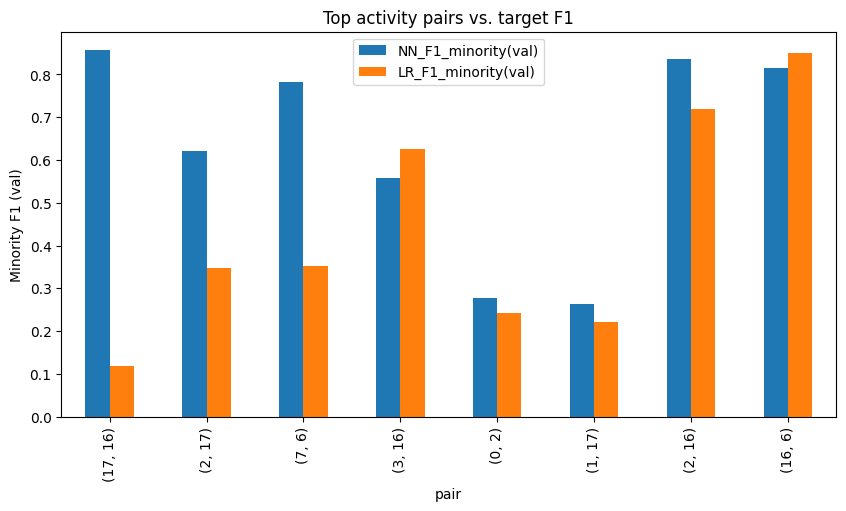

In [ ]:
import matplotlib.pyplot as plt

ax = df_top.plot(
    x="pair",
    y=["NN_F1_minority(val)", "LR_F1_minority(val)"],
    kind="bar",
    figsize=(10,5)
)
plt.ylabel("Minority F1 (val)")
plt.title("Top activity pairs vs. target F1")
plt.show()


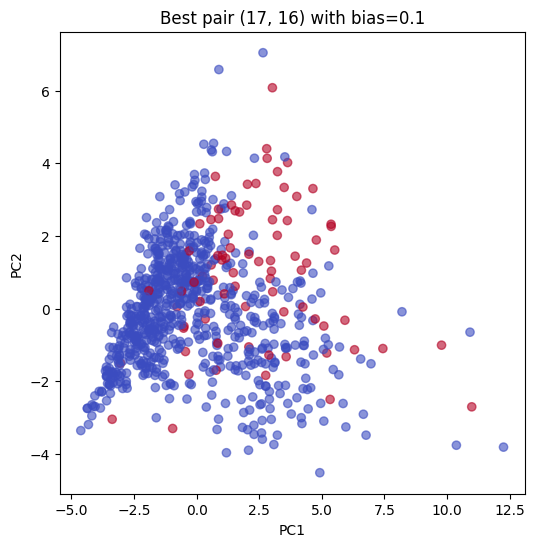

In [ ]:
Xtr, ytr = best["Xtr_2d"], best["ytr_b"]
plt.figure(figsize=(6,6))
plt.scatter(Xtr[:,0], Xtr[:,1], c=ytr, cmap="coolwarm", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Best pair {best['pair']} with bias={best['bias_pct']}")
plt.show()



In [10]:
# --- Search PAMAP2 with a third activity merged into the majority (binary eval, CUDA ready, verbose gating) ---
from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score

from dataset import Dataset
from agents.ffnn_agent2 import FFNNAgent

def _fisher_j_2class(X, y):
    X = np.asarray(X); y = np.asarray(y).astype(int)
    if len(np.unique(y)) < 2: return 0.0
    X0, X1 = X[y==0], X[y==1]
    if len(X0)==0 or len(X1)==0: return 0.0
    m0, m1 = X0.mean(axis=0), X1.mean(axis=0)
    num = float(np.sum((m1 - m0)**2))
    S0 = np.cov(X0, rowvar=False, ddof=1) if len(X0) > 1 else np.zeros((X.shape[1], X.shape[1]))
    S1 = np.cov(X1, rowvar=False, ddof=1) if len(X1) > 1 else np.zeros((X.shape[1], X.shape[1]))
    den = float(np.trace(S0 + S1))
    return 0.0 if den <= 1e-12 or not np.isfinite(den) else num / den

def _train_alpha(x_train, y_train, *, epochs=12, batch_size=64, lr=1e-3, device="cpu", seed=42):
    cfg = {
        "input_size": 2, "hidden_sizes": [32, 16], "output_size": 2,
        "learning_rate": lr, "batch_size": batch_size, "epochs": epochs,
        "type": "classification", "classes": [0, 1], "device": device, "seed": seed,
    }
    agent = FFNNAgent(**cfg)
    loader = DataLoader(TensorDataset(x_train.to(device), y_train.to(device)),
                        batch_size=batch_size, shuffle=True)
    agent.train(loader)
    return agent

def _proba_minority(agent, X_np, device="cpu"):
    with torch.no_grad():
        X = torch.tensor(X_np, dtype=torch.float32, device=device)
        p = torch.softmax(agent.model(X), dim=-1).cpu().numpy()[:, 1]
    return p

def search_pamap2_with_third_merged(
    data_path: str | Path,
    *,
    candidate_majorities=(4, 12, 16),
    candidate_minorities=(24,),
    third_activity_ids=(12, 13, 16, 5),
    bias_grid=(0.12, 0.18, 0.25),
    seeds=(42,),

    # gates
    f1_minority_range=(0.40, 0.60),
    minority_ratio_range=(0.10, 0.40),
    alpha_band=(0.40, 0.60),
    min_band_frac_minor=0.15,
    fisher_min=None,

    # split config
    pca_components=2,
    val_frac=0.20,
    test_frac=0.20,
    win_seconds=5.0,
    step_seconds=2.5,
    drop_magnetometers=True,
    use_vector_norms=True,
    stats=("std", "rms"),
    train_size=None,

    # α config
    epochs=12,
    batch_size=64,
    lr=1e-3,
    device=None,
):
    """
    Runs on CUDA:0 if available (falls back to CPU). Prints a reason as soon as a trial fails.
    """
    device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
    rows = []
    combos = list(itertools.product(candidate_majorities, candidate_minorities, third_activity_ids, bias_grid, seeds))

    def _tag(maj_id, min_id, third_id, bias_pct, seed):
        return f"(maj={maj_id}, min={min_id}, third={third_id}, bias={bias_pct:.2f}, seed={seed})"

    for maj_id, min_id, third_id, bias_pct, seed in combos:
        ds = Dataset(dataset_name="pamap2", seed=int(seed), device=device)
        ds.data_path = str(data_path)
        ds.MAJORITY_ID = int(maj_id); ds.MINORITY_ID = int(min_id)

        try:
            Xtr_t, Xva_t, Xte_t, ytr_t, yva_t, yte_t = ds.split_pamap2(
                train_size=train_size,
                bias_pct=float(bias_pct),
                val_frac=val_frac, test_frac=test_frac,
                pca_components=pca_components,
                win_seconds=win_seconds, step_seconds=step_seconds,
                drop_magnetometers=drop_magnetometers,
                use_vector_norms=use_vector_norms,
                stats=stats,
                include_third_label=True,
                third_activity_id=int(third_id),
            )
        except Exception as e:
            print(f"[warn] split failed {_tag(maj_id,min_id,third_id,bias_pct,seed)}: {e}")
            continue

        # merge third -> majority
        def _merge(y_t):
            y = y_t.detach().cpu().numpy().astype(int).ravel()
            y[y == 2] = 0
            return torch.tensor(y, dtype=torch.long, device=device)

        ytr_bin, yte_bin = _merge(ytr_t), _merge(yte_t)

        # Gate 0: degenerate label sets
        if len(np.unique(ytr_bin.cpu().numpy())) < 2 or len(np.unique(yte_bin.cpu().numpy())) < 2:
            print(f"[skip] degenerate labels {_tag(maj_id,min_id,third_id,bias_pct,seed)} (train or test not binary after merge)")
            rows.append({
                "maj_id": maj_id, "min_id": min_id, "third_id": third_id,
                "bias_pct": bias_pct, "seed": seed,
                "Alpha_F1_minority(test)": np.nan,
                "α_band_frac(minority)": np.nan,
                "train_minority_ratio": float(np.mean(ytr_bin.cpu().numpy()==1)),
                "test_minority_ratio": float(np.mean(yte_bin.cpu().numpy()==1)),
                "Fisher_J(train)": np.nan,
                "PROMISING": False,
                "why_failed": "degenerate labels after merge",
            })
            continue

        # Train α
        alpha = _train_alpha(Xtr_t.to(device), ytr_bin, epochs=epochs,
                             batch_size=batch_size, lr=lr, device=device, seed=int(seed))

        # Test metrics
        Xte = Xte_t.detach().cpu().numpy()
        yte = yte_bin.cpu().numpy().astype(int).ravel()
        p_alpha = _proba_minority(alpha, Xte, device=device)
        yhat = (p_alpha >= 0.5).astype(int)

        try:
            f1_minority = f1_score(yte, yhat, pos_label=1)
        except Exception:
            f1_minority = np.nan

        lo, hi = alpha_band
        in_band = (p_alpha >= float(lo)) & (p_alpha <= float(hi))
        band_frac_min = float(np.mean(in_band[yte==1])) if (yte==1).any() else 0.0

        # Distribution & geometry gates
        train_min_ratio = float(np.mean(ytr_bin.cpu().numpy() == 1))
        test_min_ratio  = float(np.mean(yte == 1))
        fisher_j = _fisher_j_2class(Xtr_t.detach().cpu().numpy(), ytr_bin.cpu().numpy())

        # Apply gates with immediate prints on first failure
        ok_f1 = np.isfinite(f1_minority) and (f1_minority_range[0] <= f1_minority <= f1_minority_range[1])
        if not ok_f1:
            why = f"α F1_minor={f1_minority:.3f} not in [{f1_minority_range[0]:.2f},{f1_minority_range[1]:.2f}]"
            print(f"[exclude] {why} {_tag(maj_id,min_id,third_id,bias_pct,seed)}")
            rows.append({
                "maj_id": maj_id, "min_id": min_id, "third_id": third_id,
                "bias_pct": bias_pct, "seed": seed,
                "Alpha_F1_minority(test)": f1_minority,
                "α_band_frac(minority)": band_frac_min,
                "train_minority_ratio": train_min_ratio,
                "test_minority_ratio": test_min_ratio,
                "Fisher_J(train)": fisher_j,
                "PROMISING": False,
                "why_failed": why,
            })
            continue

        ok_band = (band_frac_min >= float(min_band_frac_minor))
        if not ok_band:
            why = f"α-band(minority)={band_frac_min:.3f} < {min_band_frac_minor:.2f}"
            print(f"[exclude] {why} {_tag(maj_id,min_id,third_id,bias_pct,seed)}")
            rows.append({
                "maj_id": maj_id, "min_id": min_id, "third_id": third_id,
                "bias_pct": bias_pct, "seed": seed,
                "Alpha_F1_minority(test)": f1_minority,
                "α_band_frac(minority)": band_frac_min,
                "train_minority_ratio": train_min_ratio,
                "test_minority_ratio": test_min_ratio,
                "Fisher_J(train)": fisher_j,
                "PROMISING": False,
                "why_failed": why,
            })
            continue

        ok_ratio = (minority_ratio_range[0] <= train_min_ratio <= minority_ratio_range[1]) and \
                   (minority_ratio_range[0] <= test_min_ratio  <= minority_ratio_range[1])
        if not ok_ratio:
            why = (f"train/test minority ratio={train_min_ratio:.3f}/{test_min_ratio:.3f} "
                   f"not in [{minority_ratio_range[0]:.2f},{minority_ratio_range[1]:.2f}]")
            print(f"[exclude] {why} {_tag(maj_id,min_id,third_id,bias_pct,seed)}")
            rows.append({
                "maj_id": maj_id, "min_id": min_id, "third_id": third_id,
                "bias_pct": bias_pct, "seed": seed,
                "Alpha_F1_minority(test)": f1_minority,
                "α_band_frac(minority)": band_frac_min,
                "train_minority_ratio": train_min_ratio,
                "test_minority_ratio": test_min_ratio,
                "Fisher_J(train)": fisher_j,
                "PROMISING": False,
                "why_failed": why,
            })
            continue

        if fisher_min is not None:
            ok_fisher = np.isfinite(fisher_j) and (fisher_j >= float(fisher_min))
            if not ok_fisher:
                why = f"Fisher_J(train)={fisher_j:.3f} < {float(fisher_min):.2f}"
                print(f"[exclude] {why} {_tag(maj_id,min_id,third_id,bias_pct,seed)}")
                rows.append({
                    "maj_id": maj_id, "min_id": min_id, "third_id": third_id,
                    "bias_pct": bias_pct, "seed": seed,
                    "Alpha_F1_minority(test)": f1_minority,
                    "α_band_frac(minority)": band_frac_min,
                    "train_minority_ratio": train_min_ratio,
                    "test_minority_ratio": test_min_ratio,
                    "Fisher_J(train)": fisher_j,
                    "PROMISING": False,
                    "why_failed": why,
                })
                continue

        # Passed all gates
        print(f"[keep] promising {_tag(maj_id,min_id,third_id,bias_pct,seed)}  "
              f"F1_min={f1_minority:.3f}  band_min={band_frac_min:.3f}  "
              f"train_min={train_min_ratio:.3f} test_min={test_min_ratio:.3f}  FisherJ={fisher_j:.3f}")
        rows.append({
            "maj_id": maj_id, "min_id": min_id, "third_id": third_id,
            "bias_pct": bias_pct, "seed": seed,
            "Alpha_F1_minority(test)": f1_minority,
            "α_band_frac(minority)": band_frac_min,
            "train_minority_ratio": train_min_ratio,
            "test_minority_ratio": test_min_ratio,
            "Fisher_J(train)": fisher_j,
            "PROMISING": True,
            "why_failed": "",
        })

    df_all = pd.DataFrame(rows)
    df_hits = df_all[df_all["PROMISING"]].reset_index(drop=True)
    print(f"\n[summary] scanned={len(df_all)} promising={len(df_hits)} on device={device}")
    return df_all, df_hits


In [11]:
df_all, df_hits = search_pamap2_with_third_merged(
    data_path="/home/epigou/cs_9170_project/datasets/PAMAP2_Dataset",
    candidate_majorities=(4, 7, 5),
    candidate_minorities=(5, 24, 12, 13),
    third_activity_ids=(7, 12, 13, 4),
    bias_grid=(0.18,),
    seeds=(42,),
    device="cuda:0",   # will use GPU if available
)

print("Top promising:\n", df_hits.head(10))


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=944, rope=111 (11.76%), class0=504, class1=111, class2=329
[VAL] size=501, rope=90 (17.96%), class0=215, class1=90, class2=196
[TEST] size=584, rope=126 (21.58%), class0=232, class1=126, class2=226
PCA comps: 2 | Features in: 14 | Classes: [np.int64(0), np.int64(1), np.int64(2)]
FFNN Using device: cuda:0
[exclude] α F1_minor=0.777 not in [0.40,0.60] (maj=4, min=5, third=7, bias=0.18, seed=42)


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=850, rope=111 (13.06%), class0=505, class1=111, class2=234
[VAL] size=395, rope=71 (17.97%), class0=215, class1=71, class2=109
[TEST] size=481, rope=126 (26.20%), class0=233, class1=126, class2=122
PCA comps: 2 | Features in: 14 | Classes: [np.int64(0), np.int64(1), np.int64(2)]
FFNN Using device: cuda:0
[exclude] α F1_minor=0.956 not in [0.40,0.60] (maj=4, min=5, third=12, bias=0.18, seed=42)


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


...

[TRAIN] size=420, rope=75 (17.86%), class0=110, class1=75, class2=235
[VAL] size=315, rope=56 (17.78%), class0=149, class1=56, class2=110
[TEST] size=354, rope=108 (30.51%), class0=126, class1=108, class2=120
PCA comps: 2 | Features in: 14 | Classes: [np.int64(0), np.int64(1), np.int64(2)]
FFNN Using device: cuda:0
[exclude] α F1_minor=0.000 not in [0.40,0.60] (maj=5, min=13, third=12, bias=0.18, seed=42)


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=324, class0=112, class2=212
[VAL] size=246, class0=149, class2=97
[TEST] size=231, class0=126, class2=105
PCA comps: 2 | Features in: 14 | Classes: [np.int64(0), np.int64(2)]
[skip] degenerate labels (maj=5, min=13, third=13, bias=0.18, seed=42) (train or test not binary after merge)


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=751, rope=135 (17.98%), class0=111, class1=135, class2=505
[VAL] size=443, rope=79 (17.83%), class0=149, class1=79, class2=215
[TEST] size=464, rope=105 (22.63%), class0=127, class1=105, class2=232
PCA comps: 2 | Features in: 14 | Classes: [np.int64(0), np.int64(1), np.int64(2)]
FFNN Using device: cuda:0
[exclude] α F1_minor=0.762 not in [0.40,0.60] (maj=5, min=13, third=4, bias=0.18, seed=42)

[summary] scanned=48 promising=0 on device=cuda:0
Top promising:
 Empty DataFrame
Columns: [maj_id, min_id, third_id, bias_pct, seed, Alpha_F1_minority(test), α_band_frac(minority), train_minority_ratio, test_minority_ratio, Fisher_J(train), PROMISING, why_failed]
Index: []


In [ ]:
df_all, df_hits = search_pamap2_with_third_merged(
    data_path="/home/epigou/cs_9170_project/datasets/PAMAP2_Dataset",
    candidate_majorities=(5,),       # running
    candidate_minorities=(13,),      # descending stairs
    third_activity_ids=(7,),         # nordic walking
    bias_grid=(0.25,),          # reduced bias settings
    seeds=(42,),
    device="cuda:0"
)


/home/epigou/cs_9170_project/dataset.py:281: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


[TRAIN] size=551, rope=110 (19.96%), class0=112, class1=110, class2=329
[VAL] size=432, rope=86 (19.91%), class0=149, class1=86, class2=197
[TEST] size=457, rope=105 (22.98%), class0=127, class1=105, class2=225
PCA comps: 2 | Features in: 14 | Classes: [np.int64(0), np.int64(1), np.int64(2)]
FFNN Using device: cuda:0
[exclude] α F1_minor=0.701 not in [0.40,0.60] (maj=5, min=13, third=7, bias=0.20, seed=42)

[summary] scanned=1 promising=0 on device=cuda:0


/tmp/ipykernel_39945/1205808361.py:104: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(


14 {0: 503, 1: 110}


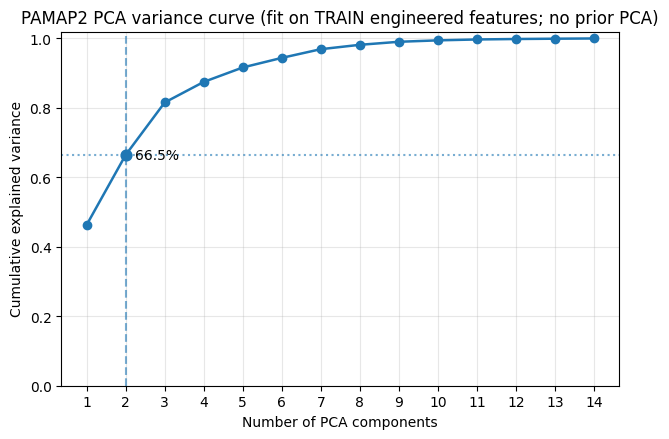

In [9]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

def plot_pamap2_variance_no_dataset(
    data_path,
    *,
    majority_id=4,                 # walking
    minority_id=24,                # rope jumping
    include_third_label=False,
    third_activity_id=None,        # e.g., 12 or 16 if include_third_label=True
    merge_third_into_majority=False,
    # windowing & features
    win_seconds=5.0,
    step_seconds=2.5,
    drop_magnetometers=True,
    use_vector_norms=True,
    stats=("std", "rms"),          # any of {"mean","std","rms"}
    # splits & bias
    val_frac=0.20,
    test_frac=0.20,
    bias_pct=0.20,                 # target rope minority share inside splits
    train_size=None,               # optional subsample after biasing
    seed=42,
    # PCA plot
    at_k=2,
    max_components=None,
    title=None,
):
    """
    End-to-end PAMAP2 preprocessing without using the Dataset class.
    Computes engineered features (no PCA), fits PCA on TRAIN (after scaling),
    and plots the cumulative explained-variance curve, highlighting k=2.

    Returns
    -------
    fig, ax, evr, cum_evr, info : (matplotlib Figure, Axes, np.ndarray, np.ndarray, dict)
      info contains basic counts and feature names.
    """
    rng = np.random.RandomState(seed)

    # ---- constants / helpers ----
    FS = 100
    WIN = int(win_seconds * FS)
    STEP = int(step_seconds * FS)
    data_dir = Path(data_path)

    imu_pos = ["hand", "chest", "ankle"]
    ACC16 = ["acc16g_x", "acc16g_y", "acc16g_z"]
    GYR   = ["gyro_x",   "gyro_y",   "gyro_z"]
    MAG   = ["mag_x",    "mag_y",    "mag_z"]

    def colnames():
        cols = ["timestamp", "activity_id", "heart_rate"]
        sub = ["temp","acc16g_x","acc16g_y","acc16g_z","acc6g_x","acc6g_y","acc6g_z",
               "gyro_x","gyro_y","gyro_z","mag_x","mag_y","mag_z",
               "orient_w","orient_x","orient_y","orient_z"]
        for p in imu_pos:
            cols += [f"{p}_{s}" for s in sub]
        return cols  # 54 per subject block + 2 base cols

    def parse_sid(path):
        m = re.search(r"subject(\d+)", Path(path).stem.lower())
        return m.group(1) if m else "unknown"

    # ---- load all .dat under Protocol/Optional ----
    files = []
    for sub in ["Protocol", "Optional", "protocol", "optional"]:
        d = data_dir / sub
        if d.exists():
            files += list(d.glob("subject*.dat"))
    if not files:
        raise FileNotFoundError(f"No .dat files found under {data_dir}/(Protocol|Optional)")

    dfs = []
    for f in sorted(files):
        df = pd.read_csv(
            f, sep=r"\s+", header=None, names=colnames(),
            engine="python", na_values=["NaN","nan"]
        )
        df["subject_id"] = parse_sid(f)
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)

    # ---- choose activities & map labels ----
    keep_ids = [majority_id, minority_id]
    if include_third_label and (third_activity_id is not None):
        keep_ids.append(int(third_activity_id))
    df = df[df["activity_id"].isin(keep_ids)].copy()

    mapping = {int(majority_id): 0, int(minority_id): 1}
    if include_third_label and (third_activity_id is not None):
        mapping[int(third_activity_id)] = 2
    df["y"] = df["activity_id"].map(mapping).astype(int)

    # ---- per-subject interpolation (no leakage) ----
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c not in ("activity_id", "y")]
    df = df.sort_values(["subject_id", "timestamp"]).groupby("subject_id", group_keys=False).apply(
        lambda g: g.assign(**{c: g[c].interpolate(limit_direction="both") for c in num_cols})
    )

    # ---- base channels (heart + acc16g + gyro +/- mag) ----
    keep_triplets = [("acc", ACC16), ("gyr", GYR)]
    if not drop_magnetometers:
        keep_triplets.append(("mag", MAG))

    base_cols = []
    if use_vector_norms:
        for p in imu_pos:
            for name, axes in keep_triplets:
                cols = [f"{p}_{a}" for a in axes]
                df[f"{p}_{name}_norm"] = np.sqrt((df[cols].values ** 2).sum(axis=1))
                base_cols.append(f"{p}_{name}_norm")
    else:
        for p in imu_pos:
            for _, axes in keep_triplets:
                for a in axes:
                    base_cols.append(f"{p}_{a}")

    base_cols = ["heart_rate"] + base_cols  # prepend HR

    # ---- windowing → per-window features (std, rms[, mean]) ----
    rows, labels, subjects = [], [], []
    df = df.sort_values(["subject_id", "timestamp"]).reset_index(drop=True)

    want_mean = ("mean" in stats)
    want_std  = ("std"  in stats)
    want_rms  = ("rms"  in stats)

    for sid, g in df.groupby("subject_id", sort=False):
        g = g.reset_index(drop=True)
        n = len(g)
        for start in range(0, max(0, n - WIN + 1), STEP):
            w = g.iloc[start:start + WIN]
            if len(w) < WIN:
                continue
            # majority label in window
            y_win = int(np.bincount(w["y"].astype(int)).argmax())
            W = w[base_cols]

            feats = {}
            if want_mean:
                feats.update(W.mean().add_suffix("__mean").to_dict())
            if want_std:
                feats.update(W.std(ddof=1).add_suffix("__std").to_dict())
            if want_rms:
                feats.update((np.sqrt((W**2).mean())).add_suffix("__rms").to_dict())

            feats["subject_id"] = sid
            rows.append(feats); labels.append(y_win); subjects.append(sid)

    feat_df = pd.DataFrame(rows).fillna(0.0)
    y_all = np.asarray(labels, dtype=int)
    subj_all = np.asarray(subjects)

    # ---- subject-aware split (train/val/test) ----
    unique_subjects = np.unique(subj_all)
    rng.shuffle(unique_subjects)

    n_subj = len(unique_subjects)
    n_test = max(1, int(round(test_frac * n_subj)))
    n_val  = max(1, int(round(val_frac  * n_subj)))
    if n_test + n_val >= n_subj:
        n_test = max(1, n_test)
        n_val  = max(1, min(n_val, n_subj - n_test - 1))

    test_subj = unique_subjects[:n_test]
    val_subj  = unique_subjects[n_test:n_test + n_val]
    train_subj= unique_subjects[n_test + n_val:]

    def mask_for(subj_list):
        return np.isin(subj_all, subj_list)

    m_train, m_val, m_test = mask_for(train_subj), mask_for(val_subj), mask_for(test_subj)

    X_train_df = feat_df[m_train].copy()
    X_val_df   = feat_df[m_val].copy()
    X_test_df  = feat_df[m_test].copy()
    y_train    = y_all[m_train]
    y_val      = y_all[m_val]
    y_test     = y_all[m_test]

    # ---- optional third -> merge into majority ----
    if include_third_label and merge_third_into_majority:
        def _merge(y):
            y = y.copy()
            y[y == 2] = 0
            return y
        y_train, y_val, y_test = _merge(y_train), _merge(y_val), _merge(y_test)

    # ---- bias rope (class 1) inside each split ----
    def apply_bias_rope(df_split, y_split, target_minority_pct, seed_local):
        dfb = df_split.copy()
        dfb["__y__"] = y_split
        mask_rope = (dfb["__y__"] == 1)
        df_rope = dfb[mask_rope]
        df_nonrope = dfb[~mask_rope]   # walking (+ third merged if applicable)

        n_nonrope = len(df_nonrope)
        n_rope = len(df_rope)
        if n_nonrope == 0 or n_rope == 0:
            out = dfb
        else:
            # want: n_rope_kept / (n_nonrope + n_rope_kept) ≈ target_minority_pct
            n_rope_keep = int(np.floor((target_minority_pct * n_nonrope) / (1 - target_minority_pct)))
            n_rope_keep = min(n_rope, max(1, n_rope_keep))
            df_rope_b = df_rope.sample(n=n_rope_keep, random_state=seed_local, replace=False)
            out = pd.concat([df_nonrope, df_rope_b], axis=0).sample(frac=1.0, random_state=seed_local).reset_index(drop=True)

        y_out = out["__y__"].to_numpy(dtype=int)
        X_out = out.drop(columns=["__y__"])
        return X_out, y_out

    X_train_b_df, y_train_b = apply_bias_rope(X_train_df, y_train, float(bias_pct), rng.randint(0, 10**6))
    X_val_b_df,   y_val_b   = apply_bias_rope(X_val_df,   y_val,   float(bias_pct), rng.randint(0, 10**6))
    # keep test distribution
    X_test_b_df,  y_test_b  = X_test_df, y_test

    # Optional subsample TRAIN after biasing
    if train_size is not None and train_size < len(X_train_b_df):
        X_train_b_df, _, y_train_b, _ = train_test_split(
            X_train_b_df, y_train_b, train_size=train_size,
            random_state=rng.randint(0, 10**6), stratify=y_train_b
        )

    # ---- scale TRAIN only (NO PCA yet) ----
    meta_cols = ["subject_id"]
    feature_cols = [c for c in X_train_b_df.columns if c not in meta_cols]

    scaler = StandardScaler()
    Xtr_z = scaler.fit_transform(X_train_b_df[feature_cols].values)

    # ---- PCA on TRAIN engineered features ----
    n_feats = Xtr_z.shape[1]
    m = int(min(max_components or n_feats, n_feats))
    k = int(max(1, min(at_k, n_feats)))

    pca = PCA(n_components=m, svd_solver="full", random_state=0)
    pca.fit(Xtr_z)

    evr = pca.explained_variance_ratio_
    cum_evr = np.cumsum(evr)
    xs = np.arange(1, m + 1)

    # ---- plot curve ----
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(xs, cum_evr, marker="o", linewidth=1.8)
    ax.axvline(k, linestyle="--", alpha=0.6)
    ax.axhline(cum_evr[k - 1], linestyle=":", alpha=0.6)
    ax.scatter([k], [cum_evr[k - 1]], s=60, zorder=3)

    ax.set_xlabel("Number of PCA components")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_ylim(0, 1.02)
    if m <= 20:
        ax.set_xticks(xs)
    ax.grid(True, alpha=0.3)

    if title is None:
        title = "PAMAP2 PCA variance curve (fit on TRAIN engineered features; no prior PCA)"
    ax.set_title(title)

    ax.text(k + 0.25, float(cum_evr[k - 1]), f"{cum_evr[k - 1]*100:.1f}%",
            va="center", ha="left")

    # ---- info block for debugging/use ----
    def _counts(y):
        vals, cnts = np.unique(y, return_counts=True)
        return {int(v): int(c) for v, c in zip(vals, cnts)}

    info = dict(
        n_features_engineered=n_feats,
        train_counts=_counts(y_train_b),
        val_counts=_counts(y_val_b),
        test_counts=_counts(y_test_b),
        feature_cols=feature_cols,
    )

    return fig, ax, evr, cum_evr, info
fig, ax, evr, cum, info = plot_pamap2_variance_no_dataset(
    data_path="/home/epigou/cs_9170_project/datasets/PAMAP2_Dataset",
    majority_id=4,
    minority_id=13,
    include_third_label=False,   # or True with third_activity_id=12
    merge_third_into_majority=False,
    bias_pct=0.18,
    win_seconds=5.0,
    step_seconds=2.5,
    drop_magnetometers=True,
    use_vector_norms=True,
    stats=("std","rms"),
    val_frac=0.20,
    test_frac=0.20,
    train_size=None,
    at_k=2,
    max_components=14,           # if you expect ~14 engineered features
    seed=42,
)
print(info["n_features_engineered"], info["train_counts"])
plt.show()
